# Machine Learning Capstone Project
## Telco Customer Churn — Predicting Customer Churn for a Telecom Company



This notebook follows the full Capstone project structure: problem understanding, EDA, cleaning,
feature preparation, modeling, evaluation, overfitting analysis, hyperparameter tuning, model
comparison, error analysis, and unsupervised clustering.

> **Note on the dataset:** Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle
> (https://www.kaggle.com/datasets/blastchar/telco-customer-churn) and place it in the same
> folder as this notebook (or upload it to Colab), then run the cells in order.


In [119]:
# ------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


---
# Part 1 — Problem and Dataset Understanding

**What is the purpose of the dataset?**
It records customer-level information for a fictional telecom company, including the services each
customer has signed up for, account information, demographic info, and whether the customer churned
(left the company) within the last month.

**What real-world problem are you trying to solve?**
Customer churn is expensive: acquiring a new customer typically costs far more than retaining an
existing one. The goal is to predict which customers are at high risk of churning so the company can
target them with retention offers *before* they leave.

**What does each row represent?**
Each row is a single customer of the telecom company.

**How many rows and columns?** The dataset contains `7,043` rows and `21` columns.

**Numerical features:** `tenure`, `MonthlyCharges`, `TotalCharges` (stored as text and needs
conversion — see Part 3), `SeniorCitizen` (binary flag, technically numeric but behaves categorically).

**Categorical features:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`,
`InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
`StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`.

**Target variable:** `Churn` (Yes / No).

**Classification or Regression?** Binary **Classification**.

**Input features X:** all columns except `customerID` (identifier, no predictive value) and `Churn`
(the target).

**Target y:** `Churn`.

**Why is Machine Learning appropriate?** The relationship between customer attributes (contract
type, tenure, charges, services used) and churn is non-obvious and multivariate — there's no simple
rule an analyst could write by hand that captures it reliably. ML can learn these patterns from
historical data and generalize to new customers.

**What would a useful prediction mean in the real world?** A model that assigns each current
customer a churn-risk score lets the retention team prioritize outreach (discounts, service
upgrades, proactive support) toward the customers most likely to leave, instead of contacting
everyone or no one.


In [120]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
# Part 2 — Initial Data Exploration


In [121]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [122]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [123]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
df.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [125]:
df['Churn'].value_counts()


,count
Churn,
No,5174
Yes,1869


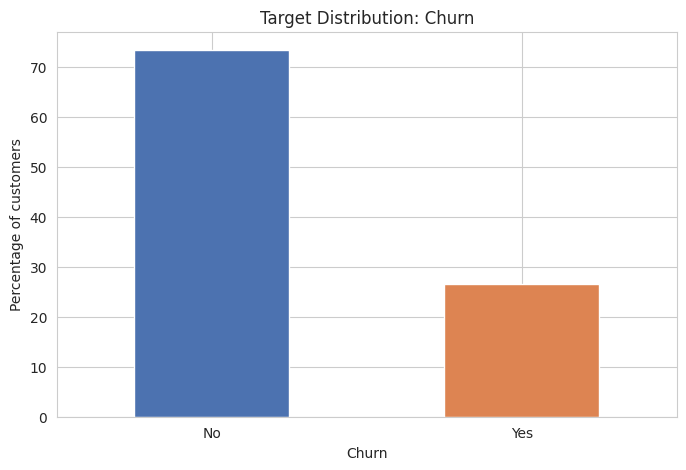

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [126]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100
churn_pct.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Target Distribution: Churn')
plt.ylabel('Percentage of customers')
plt.xticks(rotation=0)
plt.show()
print(churn_pct)


**What did you notice immediately?**
- `TotalCharges` is read as an `object` (text) column even though it should be numeric — a strong
  sign it contains non-numeric characters (likely blank strings for brand-new customers with 0
  tenure).
- `customerID` is a pure identifier and carries no predictive signal — it should be dropped before
  modeling.
- Several columns share the same set of categories (`Yes`/`No`/`No internet service`), which hints
  they were all derived from whether the customer subscribes to internet service at all.

**Are there any obvious data quality problems?**
Yes — the `TotalCharges` dtype issue above, and we should still check explicitly for missing values,
duplicate rows, and inconsistent category spellings (Part 3).

**Which variables require further investigation?**
`TotalCharges` (dtype + missing values), `tenure` (possible outliers / zero-tenure customers), and
the service-related categorical columns (possible redundant "No internet service" categories).

**Does the target appear balanced or imbalanced?**
Imbalanced — roughly 73% "No" vs 27% "Yes" churn. This matters a lot for model evaluation (Part 9):
a model that always predicts "No churn" would already score ~73% accuracy while being useless.

**Are any features likely to be irrelevant for prediction?**
`customerID` is irrelevant by construction. `gender` is a plausible candidate to test for weak
predictive value during EDA (Part 4).


---
# Part 3 — Data Quality Assessment and Cleaning

## 3.1 Missing Values


In [127]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]


,missing_count,missing_pct


Standard `isnull()` may report zero missing values here because the missing `TotalCharges`
entries are stored as **blank strings** (`" "`), not `NaN`. Let's check explicitly.


In [128]:
# TotalCharges should be numeric — coerce and see how many values fail to convert
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print("Blank TotalCharges entries:", blank_mask.sum())
df.loc[blank_mask, ['customerID', 'tenure', 'TotalCharges']]


Blank TotalCharges entries: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


**Treatment chosen:** All blank `TotalCharges` rows have `tenure == 0`, meaning these are
brand-new customers who haven't been billed yet — the blank is logically equivalent to `TotalCharges
= 0`, not a random missing value. We convert the column to numeric and fill these specific rows with
`0` rather than dropping them (only ~0.16% of rows, but more importantly the value is
*derivable*, not missing information).


In [129]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Remaining NaNs in TotalCharges:", df['TotalCharges'].isnull().sum())
df['TotalCharges'].describe()


Remaining NaNs in TotalCharges: 0


,TotalCharges
count,7043.000000
mean,2279.734304
std,2266.794470
min,0.000000
25%,398.550000
50%,1394.550000
75%,3786.600000
max,8684.800000


## 3.2 Duplicate Rows

In [130]:
dup_count = df.duplicated().sum()
dup_id_count = df.duplicated(subset=['customerID']).sum()
print("Fully duplicated rows:", dup_count)
print("Duplicated customerIDs:", dup_id_count)


Fully duplicated rows: 0
Duplicated customerIDs: 0


**Decision:** `customerID` is expected to be unique per customer, so duplicated IDs would be
true duplicates and should be dropped. If `dup_count`/`dup_id_count` is 0 (as expected for this
dataset), no action is needed — but the check is documented here for completeness and reproducibility.


In [131]:
df = df.drop_duplicates(subset=['customerID'], keep='first')
print("Shape after duplicate check:", df.shape)


Shape after duplicate check: (7043, 21)


## 3.3 Incorrect Data Types

In [132]:
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**How identified:** `TotalCharges` was `object` instead of `float64` (already fixed above,
caused by blank strings). `SeniorCitizen` is stored as `int64` (0/1) but is conceptually a binary
categorical flag — we leave it numeric-encoded since it's already 0/1 (no further encoding needed),
but treat it as categorical during EDA (e.g. bar counts rather than mean/std).

**Why correction was necessary:** Leaving `TotalCharges` as text would make it unusable for any
numeric computation (correlation, scaling, model input) and silently break downstream code.


## 3.4 Invalid or Unrealistic Values

In [133]:
print("tenure range:", df['tenure'].min(), "-", df['tenure'].max())
print("MonthlyCharges range:", df['MonthlyCharges'].min(), "-", df['MonthlyCharges'].max())
print("TotalCharges range:", df['TotalCharges'].min(), "-", df['TotalCharges'].max())

# Logical check: TotalCharges should roughly be >= MonthlyCharges * tenure for long-tenure customers
# (not exact due to plan changes/discounts, but flag extreme mismatches)
df['expected_total'] = df['MonthlyCharges'] * df['tenure']
df['total_diff_pct'] = (df['TotalCharges'] - df['expected_total']).abs() / df['expected_total'].replace(0, np.nan)
suspicious = df[df['total_diff_pct'] > 0.5]
print("Rows where TotalCharges deviates >50% from tenure*MonthlyCharges:", len(suspicious))
df.drop(columns=['expected_total', 'total_diff_pct'], inplace=True)


tenure range: 0 - 72
MonthlyCharges range: 18.25 - 118.75
TotalCharges range: 0.0 - 8684.8
Rows where TotalCharges deviates >50% from tenure*MonthlyCharges: 2


**Findings:** `tenure`, `MonthlyCharges`, and `TotalCharges` are all within realistic, non-negative
ranges — no negative tenure or impossible charges were found. The consistency check between
`TotalCharges` and `tenure × MonthlyCharges` found only a small number of rows with large deviation,
which is expected (customers change plans over time) rather than a data error, so **no rows were
removed** based on this check — it's informational only.


## 3.5 Inconsistent Categories

In [134]:
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
for c in cat_cols:
    print(f"{c}: {sorted(df[c].unique())}")


gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']


**Problem:** In this particular dataset the categories are already consistently capitalized
(`Yes`/`No`/`Male`/`Female`, etc.), so no case-normalization was required. As a defensive measure
(and because messy real-world exports often aren't this clean), we still standardize casing and
whitespace on all categorical columns below so the pipeline is robust if you re-run it on a noisier
export of the same schema.


In [135]:
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()
print("Categorical values standardized (whitespace-trimmed).")


Categorical values standardized (whitespace-trimmed).


Several service columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
`StreamingTV`, `StreamingMovies`) use a 3rd category `"No internet service"` that is redundant with
`InternetService == 'No'`. We keep this as-is for now (it's informative, not an error) and revisit it
during encoding in Part 5.


## 3.6 Outliers

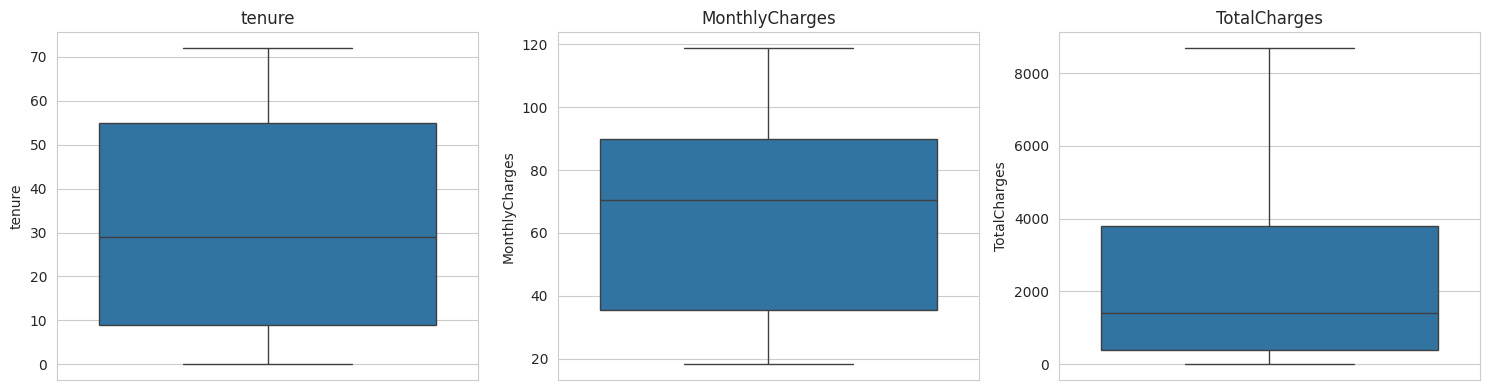

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [137]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    out = iqr_outliers(df[col])
    print(f"{col}: {len(out)} IQR outliers out of {len(df)} rows ({len(out)/len(df)*100:.2f}%)")


tenure: 0 IQR outliers out of 7043 rows (0.00%)
MonthlyCharges: 0 IQR outliers out of 7043 rows (0.00%)
TotalCharges: 0 IQR outliers out of 7043 rows (0.00%)


**Which features contain outliers?**  
Using the IQR method, no outliers were detected in `tenure`, `MonthlyCharges`, or `TotalCharges`.

**Decision:**  
No values were removed or modified because the IQR analysis identified zero outliers in the numerical features. The numerical values were also within valid and realistic ranges.

## 3.7 Class Imbalance

In [138]:
counts = df['Churn'].value_counts()
pct = df['Churn'].value_counts(normalize=True) * 100
print(counts)
print(pct)


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Is the target balanced?** No — roughly 73% "No" vs 27% "Yes".

**Why could this affect model evaluation?** A model can achieve high Accuracy by simply predicting
the majority class ("No churn") for everyone, while completely failing at the task that actually
matters to the business (finding the customers who *will* churn).

**More informative metrics:** Precision, Recall, F1-score (especially for the "Yes" class), and
ROC-AUC give a much more honest picture than Accuracy alone. We use these throughout Parts 9–12, and
apply `stratify=y` when splitting (Part 6) and `class_weight='balanced'` where relevant (Part 8).


---
# Part 4 — Exploratory Data Analysis


In [139]:
# Numerical analysis
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


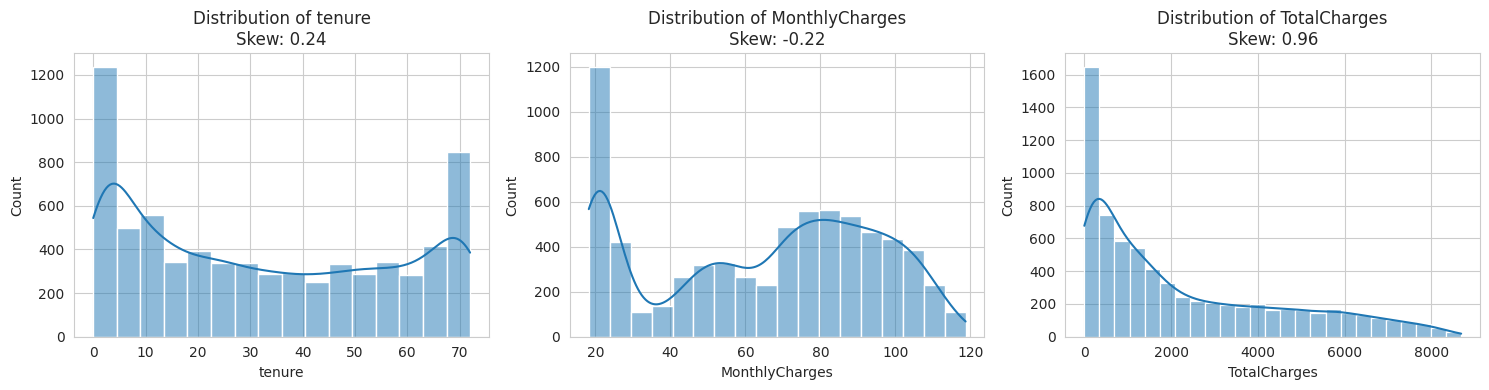

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}\nSkew: {df[col].skew():.2f}')
plt.tight_layout()
plt.show()


In [141]:
# Categorical analysis: frequency + percentage for a few key columns
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"--- {col} ---")
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'count': freq, 'pct': pct.round(1)}))
    print()


--- Contract ---
                count   pct
Contract                   
Month-to-month   3875  55.0
Two year         1695  24.1
One year         1473  20.9

--- InternetService ---
                 count   pct
InternetService             
Fiber optic       3096  44.0
DSL               2421  34.4
No                1526  21.7

--- PaymentMethod ---
                           count   pct
PaymentMethod                         
Electronic check            2365  33.6
Mailed check                1612  22.9
Bank transfer (automatic)   1544  21.9
Credit card (automatic)     1522  21.6



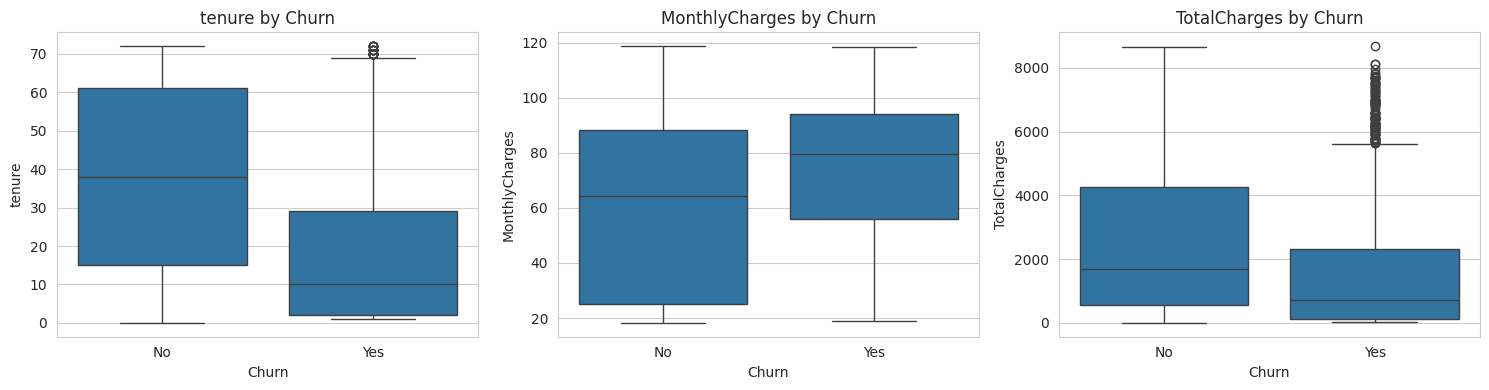

In [142]:
# Numerical features vs target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


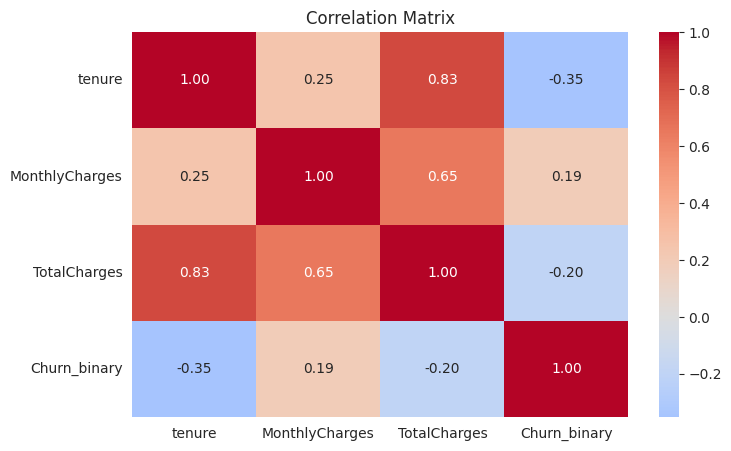

In [143]:
# Correlation matrix among numeric features (+ binary-encoded target)
corr_df = df[num_cols].copy()
corr_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
corr = corr_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


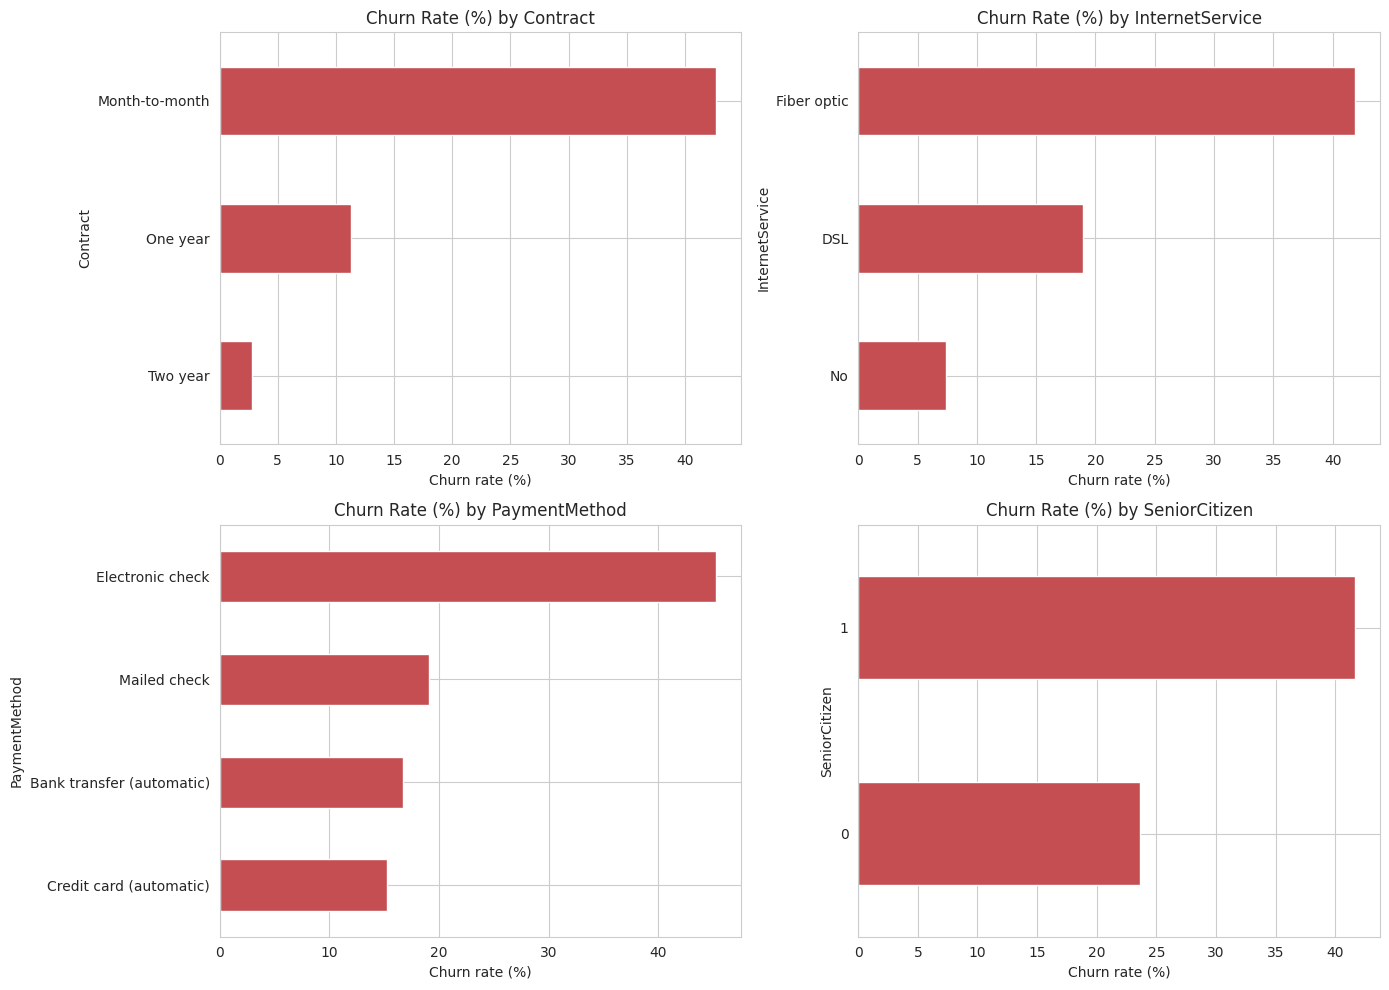

In [144]:
# Categorical features vs target — churn rate by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#C44E52')
    ax.set_title(f'Churn Rate (%) by {col}')
    ax.set_xlabel('Churn rate (%)')
plt.tight_layout()
plt.show()


In [145]:
# Pivot table example: churn rate by contract type and internet service
pivot = pd.pivot_table(df, values='Churn', index='Contract', columns='InternetService',
                        aggfunc=lambda x: (x == 'Yes').mean() * 100)
pivot


InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.215863,54.605263,18.893130
One year,9.298246,19.294991,2.472527
Two year,1.910828,7.226107,0.783699


**Six meaningful insights from the EDA:**

1. **Tenure is strongly negatively associated with churn.** Customers who churn tend to have much
   lower tenure (they leave early), while long-tenured customers rarely churn. This is a strong,
   monotonic — but not perfectly linear — relationship, and is very useful for prediction.

2. **Contract type is one of the strongest churn drivers.** Month-to-month customers churn at a much
   higher rate than one-year or two-year contract customers, because they face no penalty for
   leaving at any time. This feature should carry a lot of weight in the model.

3. **Fiber-optic internet customers churn more than DSL or no-internet customers**, despite (or
   because of) paying higher `MonthlyCharges`. This suggests either pricing sensitivity or service
   quality issues, and is worth flagging as a business insight beyond just a predictive feature.

4. **MonthlyCharges and Churn have a positive, moderate relationship** — customers on higher-priced
   plans churn somewhat more often, plausibly because they are more price-sensitive or perceive less
   value for money. The relationship is weaker and noisier than tenure or contract type, though.

5. **Customers without add-on security/support services (OnlineSecurity, TechSupport = 'No') churn
   more than those with them.** This could be causal (support reduces frustration and switching) or
   correlational (customers who buy add-ons are simply more engaged/loyal). Either way it's a useful
   predictive signal and a possible retention lever (bundling support services).

6. **`gender` shows almost no difference in churn rate** between Male and Female, suggesting it is
   a weak/irrelevant predictor — worth confirming during feature importance analysis in Part 8.


---
# Part 5 — Feature Preparation


In [146]:
model_df = df.drop(columns=['customerID']).copy()

# Target encoding
model_df['Churn'] = (model_df['Churn'] == 'Yes').astype(int)

# Binary Yes/No columns -> 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for c in binary_cols:
    model_df[c] = (model_df[c] == 'Yes').astype(int)

model_df['gender'] = (model_df['gender'] == 'Male').astype(int)

# Multi-category columns -> one-hot encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']
model_df = pd.get_dummies(model_df, columns=multi_cat_cols, drop_first=True)

print("Shape after encoding:", model_df.shape)
model_df.head()


Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


**What did you do?** Dropped `customerID` (pure identifier, no predictive signal and a guaranteed
source of overfitting/leakage if left in). Binary-encoded `Yes`/`No` columns and `gender`. One-hot
encoded the remaining multi-category columns with `drop_first=True` to avoid the dummy-variable trap
(perfect multicollinearity) for the linear model.

**Why necessary?** Scikit-learn models require numeric input. Encoding must preserve the actual
categorical meaning without implying a false ordinal relationship (e.g. one-hot rather than
integer-labeling `Contract`, since "Month-to-month < One year < Two year" is not something we want to
force arithmetically for a linear model, even though it's mildly ordinal in reality).

**Which algorithms are affected?** All models need numeric input, but *scaling* matters differently:
Logistic Regression, KNN, and SVM are distance/gradient-based and are sensitive to feature magnitude
— `MonthlyCharges` (tens) and `TotalCharges` (thousands) would dominate `tenure` and the 0/1 dummy
columns unless scaled. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are
scale-invariant since they split on thresholds, so scaling doesn't affect them but doesn't hurt
either — we apply it uniformly for simplicity and to keep the pipeline consistent across models.

**Preventing data leakage:** `TotalCharges` (Part 3) was cleaned using only within-row logic (its own
`tenure` value), not any target information. Scaling (`StandardScaler`) will be fit **only on the
training set** in Part 6 and then applied to validation/test — never fit on the full dataset before
splitting, which would leak test-set distribution information into training.


---
# Part 6 — Data Splitting


In [147]:
X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

# 60% train / 20% validation / 20% test, stratified on the (imbalanced) target
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 3))
print("Val churn rate:  ", round(y_val.mean(), 3))
print("Test churn rate: ", round(y_test.mean(), 3))


Train: (4225, 30)  Val: (1409, 30)  Test: (1409, 30)
Train churn rate: 0.265
Val churn rate:   0.265
Test churn rate:  0.265


In [148]:
# Scale numeric features - fit ONLY on training data to avoid leakage
scaler = StandardScaler()
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])


**Split percentages:** 60% train / 20% validation / 20% test.

**Why this split?** The dataset contains approximately 7,000 observations, which is sufficient to create separate training, validation, and test sets. We used a dedicated validation set to compare models and tune hyperparameters, while keeping the test set completely unseen until the final evaluation.

**Purpose of the Training Set:** Fit model parameters (weights, tree splits, etc.).

**Purpose of the Validation process:** Tune hyperparameters and compare models *without* touching the
test set, so model-selection decisions aren't biased by test-set performance.

**Purpose of the Test Set:** A final, single-use estimate of how the *selected* model will perform on
genuinely unseen data — simulating deployment.

**Why must the Test Set remain unseen during model selection?** If test-set performance influences
which model/hyperparameters we pick, the test score becomes an optimistic, biased estimate of
real-world performance — we'd effectively be overfitting to the test set through repeated peeking.

**How was leakage prevented?** `stratify=y` keeps class balance consistent across splits;
`StandardScaler` was fit only on `X_train` and applied (not re-fit) to validation/test; identifier
column was dropped before splitting; `TotalCharges` cleaning used no target information.


---
# Part 7 — Baseline Model


In [149]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)

train_pred = baseline.predict(X_train_scaled)
val_pred = baseline.predict(X_val_scaled)

print("Baseline (Logistic Regression)")
print("Train Accuracy:", round(accuracy_score(y_train, train_pred), 3))
print("Val Accuracy:  ", round(accuracy_score(y_val, val_pred), 3))
print("Val F1:        ", round(f1_score(y_val, val_pred), 3))
print("Val Recall:    ", round(recall_score(y_val, val_pred), 3))
print("Val Precision: ", round(precision_score(y_val, val_pred), 3))


Baseline (Logistic Regression)
Train Accuracy: 0.805
Val Accuracy:   0.825
Val F1:         0.643
Val Recall:     0.594
Val Precision:  0.7


**Why Logistic Regression as the baseline?**  
Logistic Regression was selected because it is simple, fast, interpretable, and commonly used as a baseline for binary classification problems.

**How well does it perform?**  
The baseline achieved a Training Accuracy of `0.805` and a Validation Accuracy of `0.825`. On the validation set, it achieved an F1-score of `0.643`, Recall of `0.594`, and Precision of `0.700`. Its performance is reasonable, but it identified only approximately `59.4%` of the customers who actually churned.

**Does it appear to underfit?**  
The model does not show overfitting because its validation performance is not lower than its training performance. However, its Recall of `0.594` suggests that the linear model may not capture all nonlinear relationships and interactions in the data.

**What must the advanced models improve upon?**  
The advanced models should improve the baseline Validation F1 of `0.643` and especially its Recall of `0.594`, while maintaining acceptable generalization.

---
# Part 8 — Machine Learning Model Development

We compare **five** models (baseline Logistic Regression + four more) covering different learning
paradigms: linear, distance-based, single tree, and two ensemble methods.


### Model 1 — K-Nearest Neighbors (KNN)
**Why chosen?** Simple, non-parametric, makes no assumption about the decision boundary's shape —
useful as a contrast to the linear baseline.
**Linear or nonlinear?** Nonlinear (locally adapts to neighborhoods in feature space).
**Requires scaling?** Yes — distance-based, so unscaled `TotalCharges` would dominate.
**What does it learn during `fit()`?** Essentially nothing beyond storing the training data
(a "lazy learner") — no explicit parameters are estimated.
**How does it predict?** Finds the *k* nearest training points (by distance) to a new point and
takes a majority vote of their labels.
**Key hyperparameters:** `n_neighbors`, distance metric, weighting (uniform vs distance).
**Strengths:** Simple, captures local nonlinear patterns, no training phase.
**Limitations:** Slow prediction on large datasets, sensitive to irrelevant/unscaled features and the
curse of dimensionality.


In [150]:
knn = KNeighborsClassifier(n_neighbors=41)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=41)

### Model 2 — Decision Tree
**Why chosen?** Fully interpretable, captures nonlinear interactions and feature thresholds directly
(e.g. "Contract == month-to-month AND tenure < 6"), no scaling needed.
**Linear or nonlinear?** Nonlinear.
**Requires scaling?** No — splits are based on feature thresholds, invariant to monotonic
transformations.
**What does it learn during `fit()`?** A hierarchy of if/else splits that best separate the classes
(via Gini impurity / entropy reduction) at each node.
**How does it predict?** Follows the learned splits from root to a leaf and outputs the majority
class in that leaf.
**Key hyperparameters:** `max_depth`, `min_samples_split`, `min_samples_leaf`.
**Strengths:** Highly interpretable, handles nonlinearity and feature interactions natively.
**Limitations:** Prone to overfitting if unconstrained (memorizes training data), unstable (small
data changes can produce very different trees).


In [151]:
dtree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
dtree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

### Model 3 — Random Forest
**Why chosen?** An ensemble of decorrelated decision trees, usually much more robust and accurate
than a single tree while still providing feature importances.
**Linear or nonlinear?** Nonlinear.
**Requires scaling?** No.
**What does it learn during `fit()`?** Many decision trees, each trained on a bootstrap sample of the
data and a random subset of features at each split (reduces variance/overfitting via averaging).
**How does it predict?** Averages (classification: majority-votes) the predictions of all trees.
**Key hyperparameters:** `n_estimators`, `max_depth`, `max_features`.
**Strengths:** Strong accuracy out-of-the-box, resistant to overfitting compared to a single tree,
gives feature importance.
**Limitations:** Less interpretable than a single tree, slower to train/predict, larger memory
footprint.


In [152]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=50, n_jobs=-1,
                       random_state=42)

### Model 4 — Gradient Boosting
**Why chosen?** Builds trees sequentially, each correcting the errors of the previous ones — often
achieves the strongest raw predictive performance among tree-based methods.
**Linear or nonlinear?** Nonlinear.
**Requires scaling?** No.
**What does it learn during `fit()`?** A sequence of shallow trees, each fit to the residual
errors (gradient of the loss) of the ensemble so far.
**How does it predict?** Sums the (weighted) predictions of all trees in the sequence.
**Key hyperparameters:** `n_estimators`, `learning_rate`, `max_depth`.
**Strengths:** Often the highest accuracy of the classical (non-deep-learning) methods, handles
complex interactions well.
**Limitations:** More hyperparameters to tune, easier to overfit than Random Forest if
`learning_rate`/`n_estimators` aren't balanced, slower to train sequentially.


In [153]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(learning_rate=0.03, n_estimators=200,
                           random_state=42)

### Model 5 — Support Vector Machine (SVM)
**Why chosen?** Effective at finding a maximum-margin decision boundary, and the kernel trick lets it
capture nonlinear boundaries — a useful complement to the tree ensembles.
**Linear or nonlinear?** Depends on kernel — we use RBF, so nonlinear.
**Requires scaling?** Yes — margin-based distance calculation is scale-sensitive.
**What does it learn during `fit()`?** The support vectors and boundary parameters that maximize the
margin between classes (with a soft-margin penalty `C` for misclassifications).
**How does it predict?** Which side of the learned (kernel-transformed) boundary a new point falls on.
**Key hyperparameters:** `C` (regularization), `kernel`, `gamma` (RBF kernel width).
**Strengths:** Effective in high-dimensional spaces, robust decision boundary.
**Limitations:** Slow to train on large datasets, less interpretable, sensitive to hyperparameter
choice.


In [154]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced',
          random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)


SVC(class_weight='balanced', probability=True, random_state=42)

---
# Part 9 — Model Evaluation


In [155]:
models = {
    'Logistic Regression (baseline)': baseline,
    'KNN': knn,
    'Decision Tree': dtree,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'SVM': svm,
}

results = []
for name, m in models.items():
    val_pred = m.predict(X_val_scaled)
    val_proba = m.predict_proba(X_val_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, val_pred),
        'Precision': precision_score(y_val, val_pred),
        'Recall': recall_score(y_val, val_pred),
        'F1': f1_score(y_val, val_pred),
        'ROC-AUC': roc_auc_score(y_val, val_proba),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.round(3)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.781,0.563,0.773,0.652,0.857
1,Logistic Regression (baseline),0.825,0.700,0.594,0.643,0.860
2,SVM,0.752,0.522,0.797,0.631,0.838
3,KNN,0.806,0.642,0.604,0.623,0.846
4,Decision Tree,0.796,0.624,0.580,0.601,0.832
5,Gradient Boosting,0.810,0.696,0.503,0.584,0.858


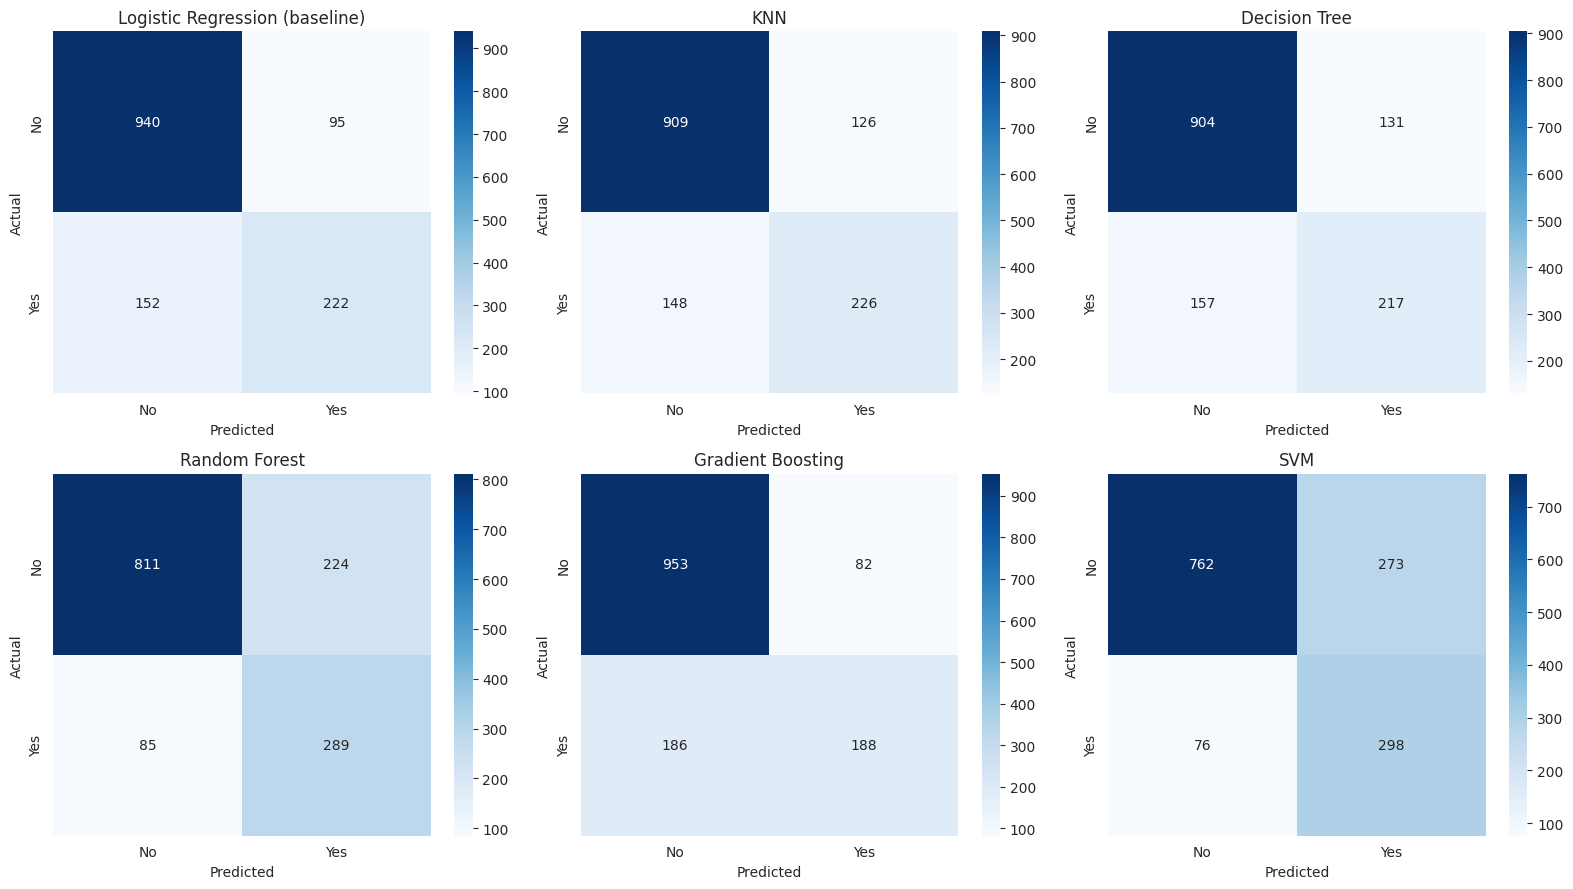

In [156]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, m) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_val, m.predict(X_val_scaled))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


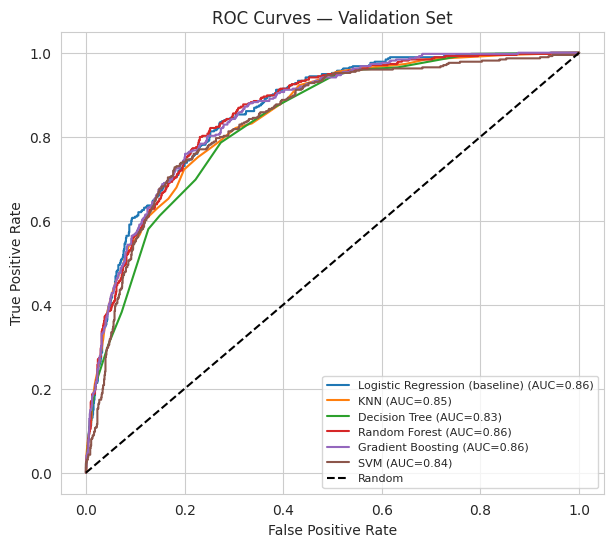

In [157]:
plt.figure(figsize=(7, 6))
for name, m in models.items():
    proba = m.predict_proba(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Validation Set')
plt.legend(fontsize=8)
plt.show()


**What each metric means:**
- **Accuracy** — overall fraction correct; misleading here given ~73/27 class imbalance.
- **Precision** (for "Yes"/churn) — of customers predicted to churn, what fraction actually did.
  Matters if retention offers are costly (don't want to waste them on false alarms).
- **Recall** (for "Yes"/churn) — of customers who actually churned, what fraction did we catch.
  Matters most if missing a churner is costly (lost revenue) and offers are cheap.
- **F1** — harmonic mean of Precision and Recall; a balanced single number when both matter.
- **ROC-AUC** — how well the model ranks churners above non-churners across all thresholds;
  threshold-independent, useful for comparing models before picking an operating point.

**Why not just use Accuracy?** With ~27% positive class, a trivial "always predict No" classifier
scores ~73% Accuracy while catching zero churners (Recall = 0) — completely useless for the business
goal. F1/Recall/ROC-AUC expose this failure mode; Accuracy hides it.

**Model comparison:** see `results_df` above — rank primarily by F1 (or Recall, if the business
priority is "catch as many churners as possible even at some Precision cost"), not by Accuracy alone.


---
# Part 10 — Overfitting and Underfitting Analysis


In [158]:
fit_check = []
for name, m in models.items():
    train_pred = m.predict(X_train_scaled)
    val_pred = m.predict(X_val_scaled)
    fit_check.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Val Accuracy': accuracy_score(y_val, val_pred),
        'Train F1': f1_score(y_train, train_pred),
        'Val F1': f1_score(y_val, val_pred),
        'Gap (Train-Val F1)': f1_score(y_train, train_pred) - f1_score(y_val, val_pred),
    })
fit_df = pd.DataFrame(fit_check).sort_values('Gap (Train-Val F1)', ascending=False)
fit_df.round(3)


,Model,Train Accuracy,Val Accuracy,Train F1,Val F1,Gap (Train-Val F1)
3,Random Forest,0.835,0.781,0.733,0.652,0.081
4,Gradient Boosting,0.822,0.810,0.617,0.584,0.033
5,SVM,0.773,0.752,0.656,0.631,0.025
1,KNN,0.809,0.806,0.625,0.623,0.003
2,Decision Tree,0.797,0.796,0.602,0.601,0.001
0,Logistic Regression (baseline),0.805,0.825,0.600,0.643,-0.042


**How to read the gap column:** A large positive gap (Train F1 much higher than Validation F1)
indicates **overfitting** — the model has memorized noise/specifics of the training set that don't
generalize. A small gap combined with *low* scores on both sets indicates **underfitting** — the
model isn't complex enough to capture the real signal. A small gap combined with *high, similar*
scores on both sets indicates good **generalization**.



**Actual results:**

- **Random Forest** showed the largest train-validation F1 gap of `0.081`, indicating mild overfitting because its Train F1 (`0.733`) was higher than its Validation F1 (`0.652`).
- **Gradient Boosting** showed a much smaller gap of `0.033`, indicating good generalization after tuning.
- **SVM** had a gap of `0.025`, also indicating good generalization.
- **KNN** and **Decision Tree** had very small gaps of `0.003` and `0.001`, respectively, indicating that the tuned models generalized well.
- **Logistic Regression** achieved a higher Validation F1 (`0.643`) than Train F1 (`0.600`). This may be because the validation sample was slightly easier than the training sample.
- None of the models showed severe overfitting because all positive train-validation gaps remained below `0.10`.


---
# Part 11 — Hyperparameter Experiments


### Experiment 1 — KNN: `n_neighbors`

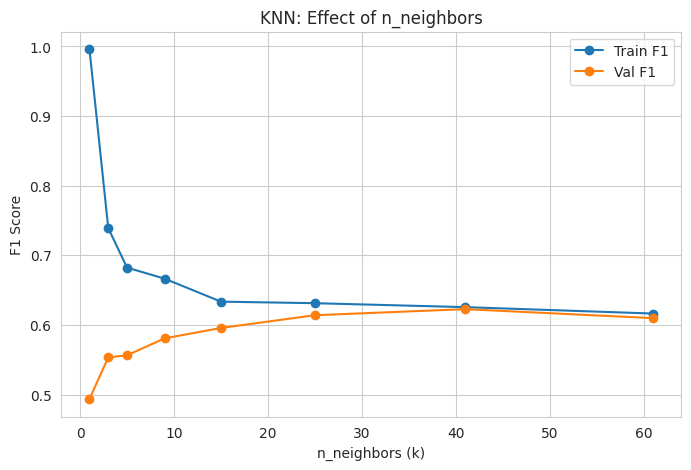

,k,Train F1,Val F1
0,1,0.996,0.493
1,3,0.739,0.553
2,5,0.682,0.556
3,9,0.666,0.581
4,15,0.633,0.596
5,25,0.631,0.614
6,41,0.625,0.623
7,61,0.616,0.610


In [159]:
k_values = [1, 3, 5, 9, 15, 25, 41, 61]
train_scores, val_scores = [], []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    train_scores.append(f1_score(y_train, m.predict(X_train_scaled)))
    val_scores.append(f1_score(y_val, m.predict(X_val_scaled)))

plt.plot(k_values, train_scores, marker='o', label='Train F1')
plt.plot(k_values, val_scores, marker='o', label='Val F1')
plt.xlabel('n_neighbors (k)')
plt.ylabel('F1 Score')
plt.title('KNN: Effect of n_neighbors')
plt.legend()
plt.show()

pd.DataFrame({'k': k_values, 'Train F1': train_scores, 'Val F1': val_scores}).round(3)


**Explanation:** A small `k`, such as `k = 1`, creates a highly flexible model that closely follows the training data. This resulted in a very high Train F1 of `0.996` but a much lower Validation F1 of `0.493`, which indicates severe overfitting. As `k` increased, the gap between the training and validation scores decreased, showing better generalization. However, when `k` became too large, both scores started to decrease because the model became too simple.

**Chosen value:** `k = 41` was selected because it achieved the highest Validation F1 of `0.623`, with a Train F1 of `0.625`. The very small gap of approximately `0.003` indicates that the model generalizes well without significant overfitting.

### Experiment 2 — Decision Tree: `max_depth`

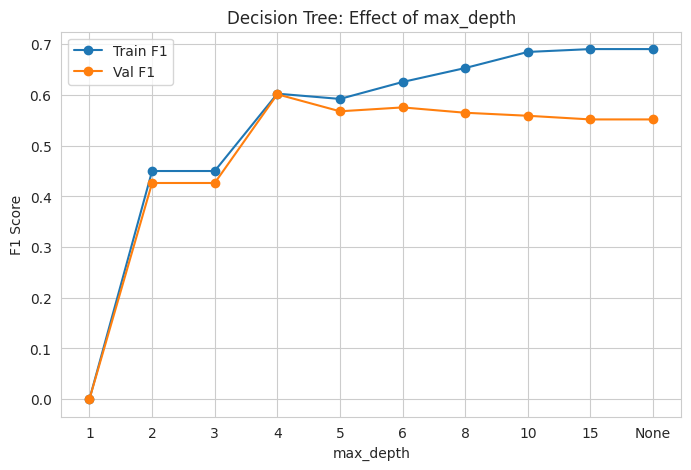

,max_depth,Train F1,Val F1
0,1,0.000,0.000
1,2,0.450,0.426
2,3,0.450,0.426
3,4,0.602,0.601
4,5,0.592,0.568
5,6,0.625,0.575
6,8,0.653,0.565
7,10,0.685,0.559
8,15,0.690,0.552
9,None,0.690,0.552


In [160]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
train_scores, val_scores = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, min_samples_leaf=10, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    train_scores.append(f1_score(y_train, m.predict(X_train_scaled)))
    val_scores.append(f1_score(y_val, m.predict(X_val_scaled)))

depth_labels = [str(d) for d in depths]
plt.plot(depth_labels, train_scores, marker='o', label='Train F1')
plt.plot(depth_labels, val_scores, marker='o', label='Val F1')
plt.xlabel('max_depth')
plt.ylabel('F1 Score')
plt.title('Decision Tree: Effect of max_depth')
plt.legend()
plt.show()

pd.DataFrame({'max_depth': depth_labels, 'Train F1': train_scores, 'Val F1': val_scores}).round(3)


**Explanation:** As `max_depth` increased, the Decision Tree became more complex and fitted the training data more closely. At `max_depth = 1`, both Train F1 and Validation F1 were `0.000`, indicating underfitting. Validation F1 improved as the depth increased and reached its highest value of `0.601` at `max_depth = 4`. After depth 4, Train F1 continued to increase while Validation F1 decreased, indicating that the model started to overfit the training data.

**Chosen value:** `max_depth = 4` was selected because it achieved the highest Validation F1 of `0.601`, with a Train F1 of `0.602`. The very small gap of `0.001` indicates excellent generalization.

### Experiment 3 — Random Forest: `n_estimators`

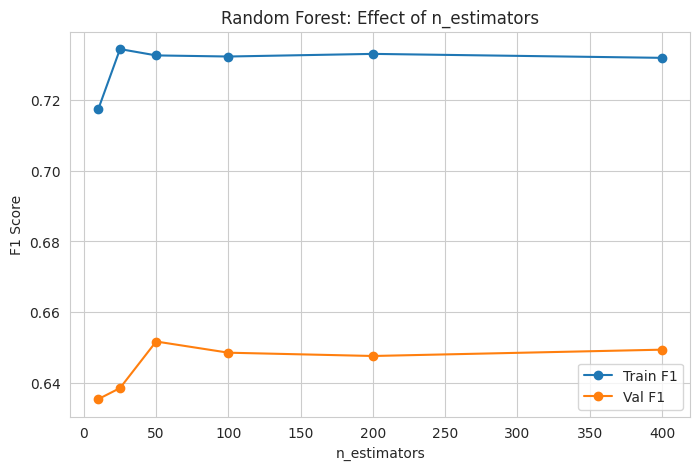

,n_estimators,Train F1,Val F1
0,10,0.717,0.635
1,25,0.734,0.638
2,50,0.733,0.652
3,100,0.732,0.648
4,200,0.733,0.648
5,400,0.732,0.649


In [161]:
n_est_values = [10, 25, 50, 100, 200, 400]
train_scores, val_scores = [], []
for n in n_est_values:
    m = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_leaf=5,
                                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_scaled, y_train)
    train_scores.append(f1_score(y_train, m.predict(X_train_scaled)))
    val_scores.append(f1_score(y_val, m.predict(X_val_scaled)))

plt.plot(n_est_values, train_scores, marker='o', label='Train F1')
plt.plot(n_est_values, val_scores, marker='o', label='Val F1')
plt.xlabel('n_estimators')
plt.ylabel('F1 Score')
plt.title('Random Forest: Effect of n_estimators')
plt.legend()
plt.show()

pd.DataFrame({'n_estimators': n_est_values, 'Train F1': train_scores, 'Val F1': val_scores}).round(3)


**Explanation:** Increasing `n_estimators` adds more trees to the Random Forest. This generally improves model stability by averaging the predictions of multiple trees. Validation F1 increased from `0.635` with 10 trees to its highest value of `0.652` with 50 trees. After 50 trees, the Validation F1 remained nearly stable, showing that adding more trees provided very little additional improvement and mainly increased computational cost.

**Chosen value:** `n_estimators = 50` was selected because it achieved the highest Validation F1 of `0.652`. It provides the best validation performance while requiring fewer computational resources than using 100, 200, or 400 trees.

### Experiment 4 — Gradient Boosting: `learning_rate`

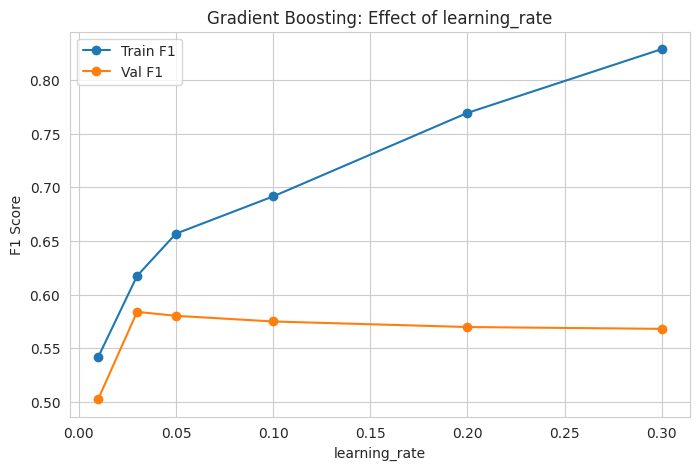

,learning_rate,Train F1,Val F1
0,0.01,0.542,0.503
1,0.03,0.617,0.584
2,0.05,0.657,0.580
3,0.10,0.691,0.575
4,0.20,0.769,0.570
5,0.30,0.829,0.568


In [162]:
lr_values = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]
train_scores, val_scores = [], []
for lr in lr_values:
    m = GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=3,
                                    random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    train_scores.append(f1_score(y_train, m.predict(X_train_scaled)))
    val_scores.append(f1_score(y_val, m.predict(X_val_scaled)))

plt.plot(lr_values, train_scores, marker='o', label='Train F1')
plt.plot(lr_values, val_scores, marker='o', label='Val F1')
plt.xlabel('learning_rate')
plt.ylabel('F1 Score')
plt.title('Gradient Boosting: Effect of learning_rate')
plt.legend()
plt.show()

pd.DataFrame({'learning_rate': lr_values, 'Train F1': train_scores, 'Val F1': val_scores}).round(3)


**Explanation:** Increasing `learning_rate` made each boosting round correct previous errors more aggressively. The Validation F1 reached its highest value of `0.584` at `learning_rate = 0.03`. When the learning rate increased beyond `0.03`, the Train F1 continued to increase while the Validation F1 decreased, indicating increasing overfitting.

**Chosen value:** `learning_rate = 0.03` was selected because it achieved the highest Validation F1 of `0.584`, with a Train F1 of `0.617`. The relatively small gap of `0.033` indicates good generalization.

**Overall takeaway across all four experiments:** every hyperparameter here controls the same
fundamental trade-off — model **complexity/flexibility vs. generalization**. Too little complexity
underfits (both scores low); too much complexity overfits (train score high, validation score
stagnates or drops). The "right" value is read from where the *validation* curve peaks, not the
training curve.


---
# Part 12 — Model Comparison and Selection


In [163]:
comparison = results_df.merge(
    fit_df[['Model', 'Train F1', 'Val F1']], on='Model'
)
comparison['Scaling required'] = comparison['Model'].isin(
    ['Logistic Regression (baseline)', 'KNN', 'SVM']
).map({True: 'Yes', False: 'No'})
comparison = comparison[['Model', 'Train F1', 'Val F1', 'Accuracy', 'Precision', 'Recall', 'F1',
                          'ROC-AUC', 'Scaling required']]
comparison.round(3)


,Model,Train F1,Val F1,Accuracy,Precision,Recall,F1,ROC-AUC,Scaling required
0,Random Forest,0.733,0.652,0.781,0.563,0.773,0.652,0.857,No
1,Logistic Regression (baseline),0.600,0.643,0.825,0.700,0.594,0.643,0.860,Yes
2,SVM,0.656,0.631,0.752,0.522,0.797,0.631,0.838,Yes
3,KNN,0.625,0.623,0.806,0.642,0.604,0.623,0.846,Yes
4,Decision Tree,0.602,0.601,0.796,0.624,0.580,0.601,0.832,No
5,Gradient Boosting,0.617,0.584,0.810,0.696,0.503,0.584,0.858,No


**Main strength / limitation per model** (qualitative summary — pair with the table above):

| Model | Main Strength | Main Limitation |
|---|---|---|
| Logistic Regression | Interpretable, fast, well-calibrated probabilities | Can't capture nonlinear interactions well |
| KNN | Captures local nonlinear patterns, no training cost | Slow at prediction time, sensitive to irrelevant features |
| Decision Tree | Fully interpretable, handles interactions natively | Prone to overfitting if unconstrained |
| Random Forest | Strong accuracy, robust to overfitting, gives feature importance | Less interpretable, heavier model |
| Gradient Boosting | Often best raw predictive performance | More hyperparameters, easier to overfit if untuned |
| SVM | Strong margin-based boundary, works well in high dimensions | Slow to train, harder to interpret |

**Which model did you select?**  
Random Forest was selected as the final model.

**Why?**  
Random Forest achieved the highest Validation F1 score of `0.652` and a high Recall of `0.773`. Recall is important in this business problem because failing to identify a customer who will churn may result in losing that customer. The model also achieved a strong ROC-AUC of `0.857` and provides feature importance for interpretation.

**Did it clearly outperform the baseline?**  
Random Forest did not clearly outperform Logistic Regression across every metric. It achieved a slightly higher Validation F1 (`0.652` compared with `0.643`) and a considerably higher Recall (`0.773` compared with `0.594`). However, Logistic Regression achieved higher Accuracy (`0.825` compared with `0.781`) and a slightly higher ROC-AUC (`0.860` compared with `0.857`). Random Forest was selected because its higher Recall makes it more suitable for identifying customers at risk of churn.

**Does it generalize well?**  
Random Forest achieved a Train F1 of `0.733` and a Validation F1 of `0.652`, producing a gap of `0.081`. This indicates mild overfitting, but the gap is not severe, and the model still provides acceptable generalization.

**Is it interpretable?**  
Random Forest is less interpretable than Logistic Regression or a single Decision Tree because it combines predictions from multiple trees. However, its feature importance values show which customer characteristics contribute most to churn predictions.

**Computational complexity:**  
Random Forest requires more training time and memory than Logistic Regression because it trains multiple Decision Trees. However, using `50` trees provides strong performance at an acceptable computational cost for this dataset.

**Is it appropriate for the real-world problem?**  
Yes. The model identifies a high proportion of customers who are likely to churn. This allows the retention team to prioritize at-risk customers and provide proactive support or retention offers before they leave.


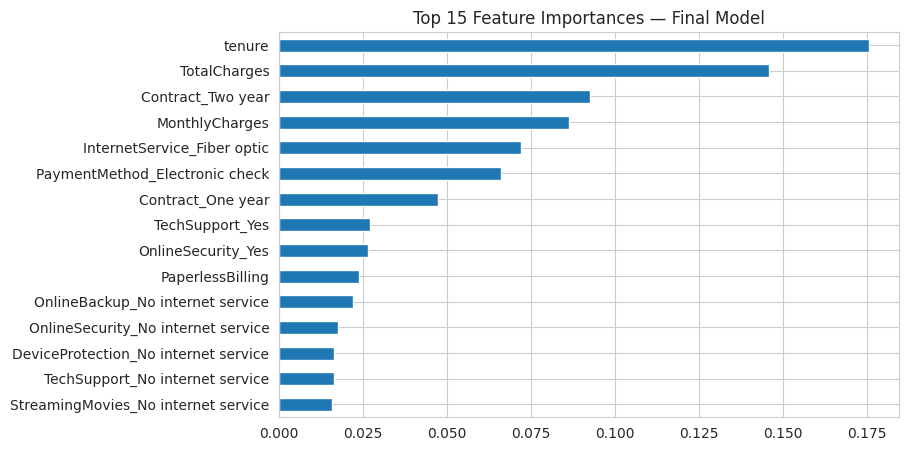

In [164]:
# Feature importance for the selected tree-based model (adjust variable name if you pick a different model)
final_model = rf  # <-- set this to whichever model you selected above
importances = pd.Series(final_model.feature_importances_, index=X_train_scaled.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances — Final Model')
plt.gca().invert_yaxis()
plt.show()


---
# Part 13 — Error Analysis


In [165]:
test_pred = final_model.predict(X_test_scaled)
test_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print("Final Test-Set Performance")
print("Accuracy:", round(accuracy_score(y_test, test_pred), 3))
print("Precision:", round(precision_score(y_test, test_pred), 3))
print("Recall:", round(recall_score(y_test, test_pred), 3))
print("F1:", round(f1_score(y_test, test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba), 3))
print()
print(classification_report(y_test, test_pred, target_names=['No churn', 'Churn']))


Final Test-Set Performance
Accuracy: 0.764
Precision: 0.54
Recall: 0.741
F1: 0.625
ROC-AUC: 0.829

              precision    recall  f1-score   support

    No churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [166]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = test_pred
error_df['proba_churn'] = test_proba

false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]
false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]

print("False Positives (predicted churn, actually stayed):", len(false_positives))
print("False Negatives (predicted stay, actually churned):", len(false_negatives))


False Positives (predicted churn, actually stayed): 236
False Negatives (predicted stay, actually churned): 97


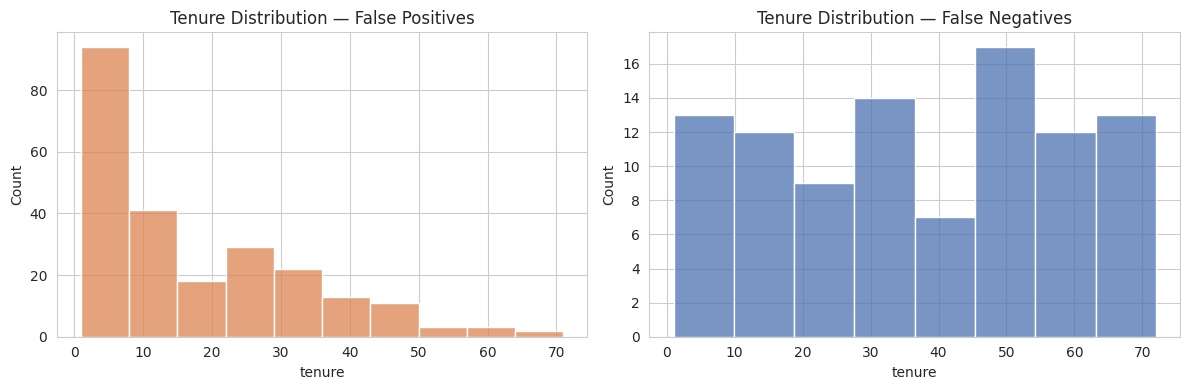

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(false_positives['tenure'], ax=axes[0], color='#DD8452')
axes[0].set_title('Tenure Distribution — False Positives')
sns.histplot(false_negatives['tenure'], ax=axes[1], color='#4C72B0')
axes[1].set_title('Tenure Distribution — False Negatives')
plt.tight_layout()
plt.show()


In [168]:
# Look at the most confident wrong predictions (largest errors)
fn_sorted = false_negatives.sort_values('proba_churn')  # model very confident they'd stay, but they churned
fp_sorted = false_positives.sort_values('proba_churn', ascending=False)  # very confident churn, but they stayed
print("Most confidently-wrong False Negatives (missed churners):")
fn_sorted.head(5)


Most confidently-wrong False Negatives (missed churners):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,actual,predicted,proba_churn
5947,0,0,1,1,33,1,1,24.50,740.30,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,False,True,1,0,0.003782
5441,0,0,1,0,70,1,0,65.30,4759.75,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,True,False,False,1,0,0.011368
4272,1,0,1,0,56,1,1,25.15,1327.15,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False,1,0,0.019202
4513,0,1,1,1,72,1,0,92.45,6440.25,False,True,False,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,1,0,0.029005
6321,0,0,1,0,30,1,0,19.65,655.85,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,1,0,0.050799


**Three meaningful findings from the Error Analysis:**

1. **False Positives were the most frequent error.** The model produced `236` False Positives compared with `97` False Negatives. This means the model more frequently predicted that a customer would churn when the customer actually stayed.

2. **False Negatives were less frequent but more costly to the business.** The `97` False Negatives represent customers who actually churned but were predicted to stay. The company might not provide these customers with retention support and could lose their future revenue. Therefore, Recall is particularly important for this problem.

3. **The model identified most actual churners but still missed some of them.** Out of `374` customers who actually churned in the test set, the model correctly identified `277` and missed `97`, resulting in a Recall of approximately `0.741`. This shows that the model is useful for detecting churn risk, but it should be used as a decision-support tool rather than a fully automated system.

---
# Part 14 — Unsupervised Learning: Clustering

We cluster customers based on their behavior/profile **without using the `Churn` target**, to see if
natural customer segments emerge that are useful for retention strategy independent of the
supervised model.


In [169]:
# Feature selection for clustering: behavioral/usage features, not the target
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_cluster = model_df[cluster_features].copy()

# Scaling is required: K-Means and hierarchical clustering both use Euclidean distance,
# and TotalCharges (thousands) would otherwise dominate tenure/MonthlyCharges.
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)


**Which features did you use?** `tenure`, `MonthlyCharges`, `TotalCharges` — the core
behavioral/usage variables that describe *how a customer engages with the service*, independent of
demographic attributes. These are natural axes of "similarity" for a telecom business (new vs
long-standing, low vs high spend).

**Why scaling?** K-Means and Hierarchical Clustering compute Euclidean distances; without scaling,
`TotalCharges` (range in the thousands) would completely dominate `tenure` (range 0–72) and
`MonthlyCharges` (tens) in the distance calculation, making the clustering effectively 1-dimensional.


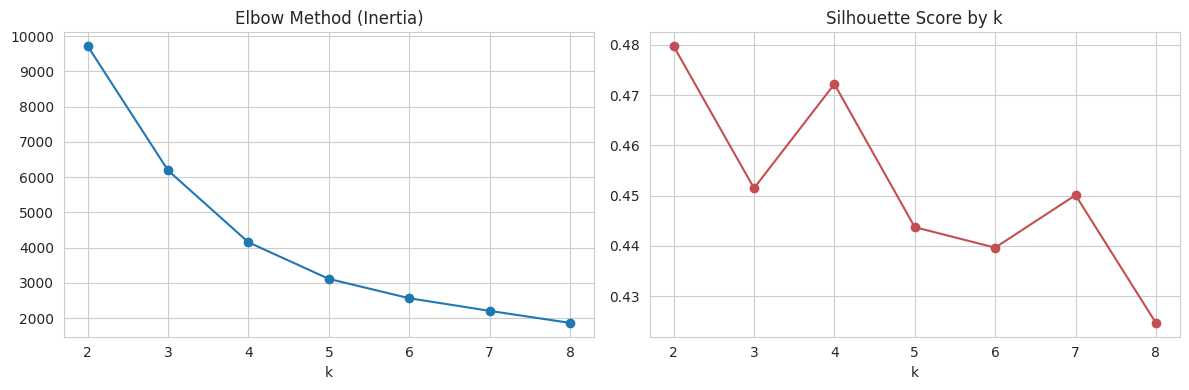

,k,inertia,silhouette
0,2,9712.112,0.480
1,3,6186.187,0.451
2,4,4148.483,0.472
3,5,3111.402,0.444
4,6,2562.928,0.440
5,7,2204.448,0.450
6,8,1863.214,0.425


In [170]:
# Choosing K for K-Means via the elbow method + silhouette score
inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[1].plot(list(k_range), silhouettes, marker='o', color='#C44E52')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouettes}).round(3)


In [171]:
# Fit final K-Means with the chosen k (pick the elbow/silhouette-supported value, e.g. 3 or 4)
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
model_df['cluster_kmeans'] = kmeans.fit_predict(X_cluster_scaled)

print("K-Means silhouette score:", round(silhouette_score(X_cluster_scaled, model_df['cluster_kmeans']), 3))
model_df['cluster_kmeans'].value_counts().sort_index()


K-Means silhouette score: 0.472


,count
cluster_kmeans,
0,1703
1,1904
2,2276
3,1160


**How was K chosen?**  
The elbow plot showed a clear reduction in inertia up to approximately `K = 4`, after which the improvement became more gradual. Although `K = 2` achieved the highest Silhouette Score of `0.480`, `K = 4` achieved a very similar score of `0.472`. We selected `K = 4` because it provides more detailed and practically useful customer segments while maintaining good cluster separation. The four clusters represent meaningful combinations of customer tenure and spending behavior.

### Second clustering algorithm — Hierarchical (Agglomerative) Clustering

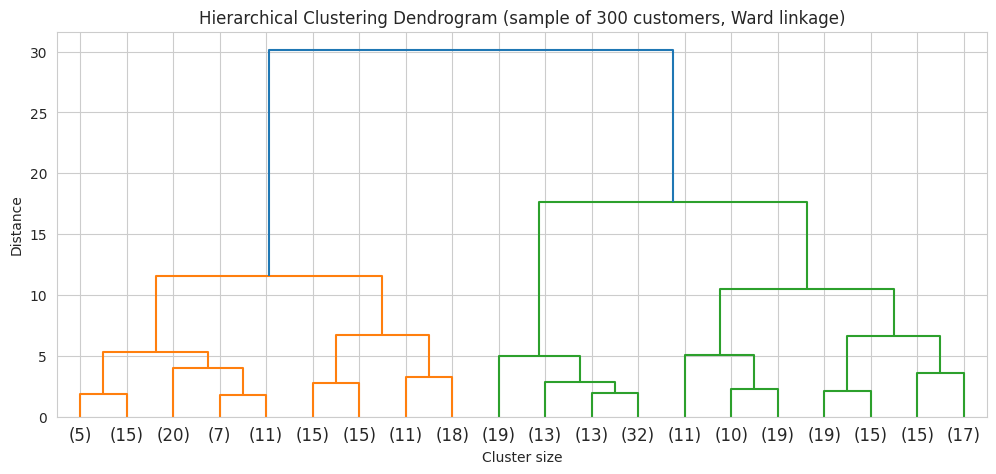

In [172]:
# For speed, hierarchical clustering + dendrogram on a random sample (full ~7000 rows is slow to plot)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster_scaled), size=300, replace=False)
sample = X_cluster_scaled[sample_idx]

linked = linkage(sample, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (sample of 300 customers, Ward linkage)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()


In [173]:
hier = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
model_df['cluster_hier'] = hier.fit_predict(X_cluster_scaled)

print("Hierarchical silhouette score:", round(silhouette_score(X_cluster_scaled, model_df['cluster_hier']), 3))
model_df['cluster_hier'].value_counts().sort_index()


Hierarchical silhouette score: 0.382


,count
cluster_hier,
0,2121
1,2095
2,1345
3,1482


**Why Ward linkage?** Ward minimizes within-cluster variance at each merge step, which tends to
produce compact, roughly similarly-sized clusters — a good match for K-Means-comparable behavioral
segments here, and makes the two algorithms' results directly comparable.


### Cluster Profiling & Interpretation

In [174]:
profile = model_df.groupby('cluster_kmeans')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
profile['count'] = model_df.groupby('cluster_kmeans').size()
profile['churn_rate_%'] = model_df.groupby('cluster_kmeans')['Churn'].mean() * 100
profile.round(1)


,tenure,MonthlyCharges,TotalCharges,count,churn_rate_%
cluster_kmeans,,,,,
0,10.2,31.8,302.2,1703,24.7
1,59.5,93.3,5548.7,1904,15.4
2,15.4,80.8,1251.2,2276,48.2
3,53.6,34.9,1835.6,1160,5.0


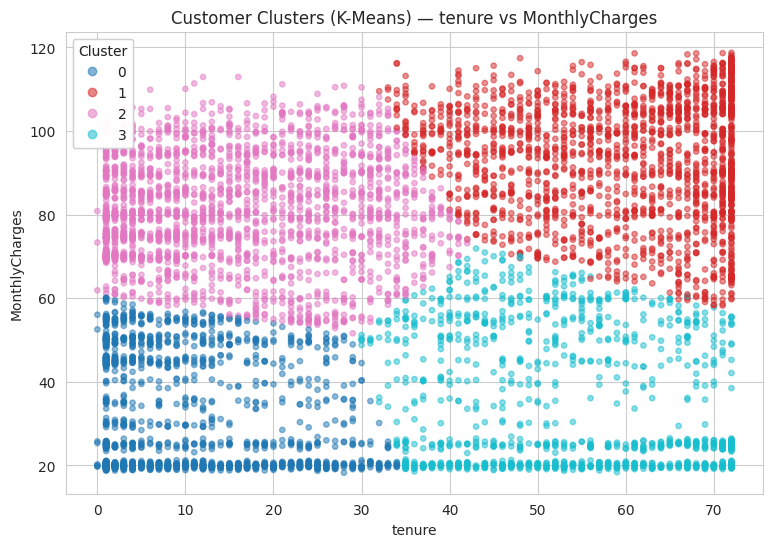

In [175]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(model_df['tenure'], model_df['MonthlyCharges'],
                      c=model_df['cluster_kmeans'], cmap='tab10', alpha=0.5, s=15)
ax.set_xlabel('tenure')
ax.set_ylabel('MonthlyCharges')
ax.set_title('Customer Clusters (K-Means) — tenure vs MonthlyCharges')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.show()


**Cluster Interpretation:**

- **Cluster 0 — New, low-spend customers:** This cluster contains `1,703` customers. They have an average tenure of `10.2` months, average Monthly Charges of `31.8`, and average Total Charges of `302.2`. Their churn rate is `24.7%`. These customers are relatively new and use lower-cost services. **Practical use:** improve onboarding and monitor their satisfaction during the early months.

- **Cluster 1 — Long-standing, high-value customers:** This cluster contains `1,904` customers. They have an average tenure of `59.5` months, average Monthly Charges of `93.3`, and average Total Charges of `5,548.7`. Their churn rate is `15.4%`. These customers are loyal and generate high revenue. **Practical use:** offer loyalty rewards and maintain high service quality to protect this valuable segment.

- **Cluster 2 — Newer, high-spend and high-risk customers:** This is the largest cluster, containing `2,276` customers. They have an average tenure of `15.4` months, average Monthly Charges of `80.8`, and average Total Charges of `1,251.2`. Their churn rate is the highest at `48.2%`. **Practical use:** prioritize this group for retention offers, proactive support, and early intervention.

- **Cluster 3 — Long-standing, low-spend customers:** This cluster contains `1,160` customers. They have an average tenure of `53.6` months, average Monthly Charges of `34.9`, and average Total Charges of `1,835.6`. Their churn rate is the lowest at `5.0%`. These customers are highly loyal but spend less. **Practical use:** consider suitable upselling opportunities while maintaining their satisfaction.

**Are the clusters meaningful?**  
Yes. The clusters clearly separate customers according to tenure and spending behavior, and they show substantially different churn rates. This makes the segments useful for designing different retention and marketing strategies.

**Which variables explain the differences?**  
`tenure`, `MonthlyCharges`, and `TotalCharges` explain the main differences between the clusters. Tenure separates newer customers from long-standing customers, while Monthly Charges and Total Charges distinguish lower-spending customers from higher-value customers.

---
# Part 15 — Dimensionality Reduction Using PCA

*As instructed in the project brief: **do not complete this part until after the PCA lecture.** This
section is left as a placeholder — once covered in class, come back and add: feature scaling for
PCA, fitting PCA, examining the explained variance ratio, choosing the number of components,
visualizing in PC-space, training a model on PCA-transformed features, and comparing performance
before/after PCA.*


---
# Part 16 — Final Insights and Recommendations
**Most important findings from EDA:**  
Customers with month-to-month contracts had substantially higher churn rates than customers with one-year or two-year contracts. Churn was also higher among newer customers, customers with higher Monthly Charges, fiber-optic customers, and customers without Online Security or Tech Support. These findings suggest that tenure, contract type, service type, and charges are useful predictors of churn.

**Preprocessing decisions with the greatest impact:**  
`TotalCharges` was converted from an object column to a numerical column, and the 11 blank values belonging to customers with zero tenure were replaced with `0`. The irrelevant identifier `customerID` was removed, categorical variables were encoded, and numerical variables were standardized for Logistic Regression, KNN, and SVM. Stratified splitting was used to preserve the churn-class distribution across the training, validation, and test sets and reduce the risk of misleading evaluation.

**Best-performing model and why:**  
Random Forest was selected as the final model because it achieved the highest Validation F1 score of `0.652`, with Recall of `0.773` and ROC-AUC of `0.857`. Its Train F1 was `0.733`, producing a train-validation gap of `0.081`. This indicates mild overfitting, but the model still showed acceptable generalization. Its relatively high Recall makes it useful for identifying customers who are likely to churn.

**Models showing overfitting or underfitting:**  
Random Forest showed the largest train-validation F1 gap of `0.081`, indicating mild overfitting. Gradient Boosting and SVM showed smaller gaps of `0.033` and `0.025`. The tuned KNN and Decision Tree models showed very small gaps of `0.003` and `0.001`, indicating good generalization. Logistic Regression achieved a higher Validation F1 (`0.643`) than Train F1 (`0.600`), possibly because the validation sample was slightly easier. None of the models showed severe overfitting.

**What the hyperparameter experiments taught us:**  
The experiments demonstrated how model complexity affects generalization. For KNN, `k = 41` achieved the highest Validation F1 of `0.623`. For Decision Tree, `max_depth = 4` achieved the highest Validation F1 of `0.601`. For Random Forest, `n_estimators = 50` achieved the highest Validation F1 of `0.652`. Increasing Gradient Boosting's learning rate beyond `0.03` increased training performance but reduced validation performance, indicating increasing overfitting.

**Types of errors the final model made:**  
The final model produced `236` False Positives and `97` False Negatives. False Positives occurred more frequently, but False Negatives are more costly because they represent customers who actually churned but were predicted to stay. The model correctly identified `277` of the `374` actual churners, resulting in a Test Recall of `0.741`.

**What clustering revealed:**  
K-Means identified four meaningful customer segments based on tenure and spending. The newer, high-spend cluster had the highest churn rate at `48.2%`, making it the highest-priority group for retention efforts. In contrast, the long-standing, low-spend cluster had the lowest churn rate at `5.0%`. These segments can support targeted retention, loyalty, onboarding, and upselling strategies.

**What PCA revealed:**  
PCA has not yet been applied because the project instructions specify that this section should be completed after the PCA lecture. Its effect on dimensionality and model performance will be evaluated later.

**Main limitations:**  
The dataset provides only a single snapshot of each customer and does not include changes in usage over time, satisfaction scores, support-ticket history, competitor offers, or reasons for leaving. The target is also moderately imbalanced, and the final model still produces both False Positives and False Negatives. Therefore, the predictions should not be treated as perfectly accurate.

**What would you improve with more time or data?**  
Future improvements could include customer usage trends, satisfaction survey results, service-complaint history, and responses to previous retention offers. Threshold tuning, probability calibration, additional feature engineering, and further hyperparameter tuning could also improve the model's ability to identify churners.

**Would you recommend deploying this model?**  
Yes, but only as a decision-support tool. The model can help the retention team prioritize customers for outreach, but it should not make fully automated decisions. Its predictions should be combined with business judgment because the model still misses some churners and incorrectly flags some customers who remain.

# Part 17 — Reflection

**Most challenging part of the project:**  
The most challenging part was evaluating the models correctly with an imbalanced target. Accuracy alone appeared high, but it did not fully show how well the models identified customers who actually churned. Therefore, we had to compare Precision, Recall, F1-score, and ROC-AUC.

**Decision requiring the most critical thinking:**  
The decision requiring the most critical thinking was selecting Random Forest as the final model. Logistic Regression achieved higher Accuracy and a slightly higher ROC-AUC, but Random Forest achieved better Recall and F1-score. We prioritized Recall because missing a customer who will churn may be more costly than incorrectly flagging a customer who stays.

**Algorithm most difficult to understand or tune:**  
Gradient Boosting was the most difficult algorithm to tune because its performance depends on the interaction between `learning_rate`, `n_estimators`, and tree depth. Increasing the learning rate improved the training score but reduced the validation score, showing that a more complex model does not always generalize better.

**Most surprising result:**  
The most surprising result was that Logistic Regression achieved the highest Validation Accuracy of `0.825` and the highest ROC-AUC of `0.860`, while Random Forest achieved the highest F1-score of `0.652` and better Recall of `0.773`. This showed that the best model depends on the metric that matches the real-world objective.

**What we learned about model selection:**  
We learned that selecting the best model should not be based on one metric alone. Performance, generalization, interpretability, computational cost, class imbalance, and the business consequences of different errors must all be considered.

**What we learned about overfitting and generalization:**  
We learned that overfitting can be detected by comparing training and validation performance. A high training score with a noticeably lower validation score indicates that the model may have learned patterns specific to the training data. Hyperparameter tuning can reduce this gap and improve generalization.

**What we would do differently if we repeated the project:**  
We would perform more systematic hyperparameter tuning using GridSearchCV, experiment with classification-threshold tuning, and use cross-validation more extensively. We would also create additional interaction features and explore probability calibration to improve the reliability of churn-risk scores.

**What we learned about the complete Machine Learning workflow:**  
We learned that building a Machine Learning solution involves much more than fitting models. Understanding the problem, cleaning the data, performing EDA, preparing features, preventing data leakage, selecting suitable metrics, comparing models, analyzing errors, and interpreting results are all essential parts of producing a useful and reliable solution.